In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Creating the directory structure to save Graphs and Output for Each Evaluator

In [13]:
output_data_path = os.path.join("output", "combined")
os.makedirs(output_data_path, exist_ok=True)

Reading the Evaluation data by Pathologist

In [14]:
evaluator_ids = ['evaluator1', 'evaluator2', 'evaluator3', 'evaluator4', 'evaluator5']
correct_answers_eval_data = {}
for evaluator_id in evaluator_ids:
    correct_answer_eval_data_path = f"output/{evaluator_id}/pathvqa_correct_answer_eval_data.pkl"
    eval_data = pd.read_pickle(correct_answer_eval_data_path)
    correct_answers_eval_data[evaluator_id] = eval_data

#### Combining all the dataframes into one combined dataframe for each Question Type and Evaluation Benchmark of Correct Answers

Open-Ended Knowledge Interpretation

In [15]:
correct_answers_open_ended_know_inter = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator5')])

correct_answers_open_ended_know_inter['Level 2'] = round((correct_answers_open_ended_know_inter['Level 2']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level 1'] = round((correct_answers_open_ended_know_inter['Level 1']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level 0'] = round((correct_answers_open_ended_know_inter['Level 0']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level -1'] = round((correct_answers_open_ended_know_inter['Level -1']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter = correct_answers_open_ended_know_inter.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                      'Level 0': '0',
                                                                                                                      'Level -1': '-1'})

correct_answers_open_ended_know_inter

,2,1,0,-1
Evaluator1,54.92,15.57,10.66,18.85
Evaluator2,40.16,9.84,9.84,40.16
Evaluator3,50.00,26.23,10.66,13.11
Evaluator4,59.84,33.61,3.28,3.28
Evaluator5,84.68,0.81,2.42,12.10


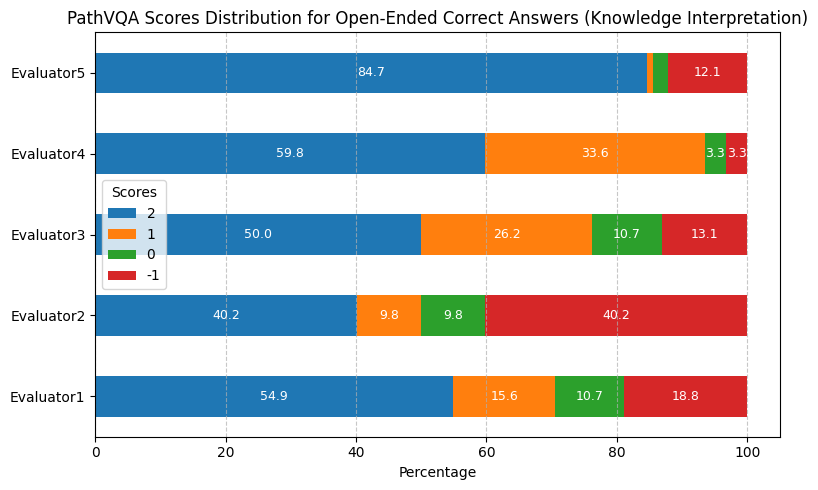

In [16]:
ax = correct_answers_open_ended_know_inter.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('PathVQA Scores Distribution for Open-Ended Correct Answers (Knowledge Interpretation)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathvqa_open_ended_correct_answers_know_inter.png')
plt.show()

Open-Ended Visual Grounding

In [17]:
correct_answers_open_ended_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator5')])

correct_answers_open_ended_vis_grounding['Level 2'] = round((correct_answers_open_ended_vis_grounding['Level 2']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level 1'] = round((correct_answers_open_ended_vis_grounding['Level 1']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level 0'] = round((correct_answers_open_ended_vis_grounding['Level 0']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level -1'] = round((correct_answers_open_ended_vis_grounding['Level -1']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding = correct_answers_open_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                      'Level 0': '0',
                                                                                                                      'Level -1': '-1'})

correct_answers_open_ended_vis_grounding

,2,1,0,-1
Evaluator1,56.56,14.75,9.84,18.85
Evaluator2,35.25,8.20,16.39,40.16
Evaluator3,52.46,21.31,13.93,12.30
Evaluator4,70.49,26.23,0.82,2.46
Evaluator5,83.06,1.61,4.84,10.48


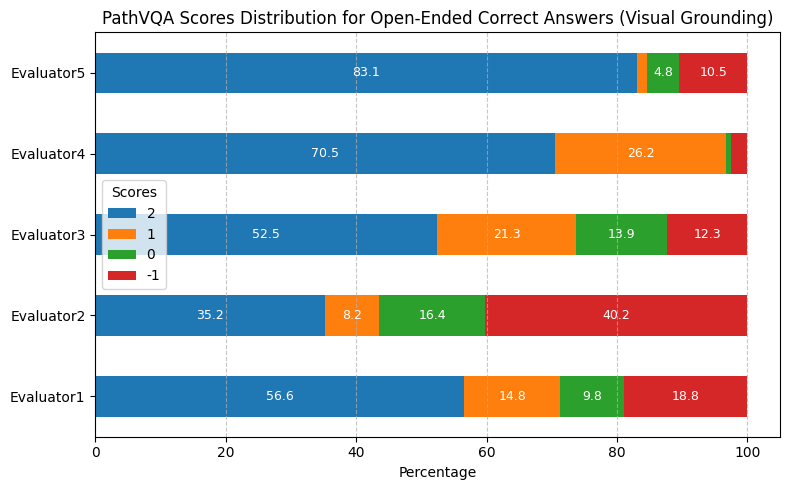

In [18]:
ax = correct_answers_open_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('PathVQA Scores Distribution for Open-Ended Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathvqa_open_ended_correct_answers_vis_grounding.png')
plt.show()

Close-Ended Visual Grounding

In [19]:
correct_answers_close_ended_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator5')])

correct_answers_close_ended_vis_grounding['Level 2'] = round((correct_answers_close_ended_vis_grounding['Level 2']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level 1'] = round((correct_answers_close_ended_vis_grounding['Level 1']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level 0'] = round((correct_answers_close_ended_vis_grounding['Level 0']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level -1'] = round((correct_answers_close_ended_vis_grounding['Level -1']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding = correct_answers_close_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                'Level 0': '0',
                                                                                                                'Level -1': '-1'})

correct_answers_close_ended_vis_grounding

,2,1,0,-1
Evaluator1,100.0,0.0,0.0,0.0
Evaluator2,30.0,10.0,0.0,60.0
Evaluator3,30.0,0.0,0.0,70.0
Evaluator4,60.0,30.0,0.0,10.0
Evaluator5,70.0,0.0,0.0,30.0


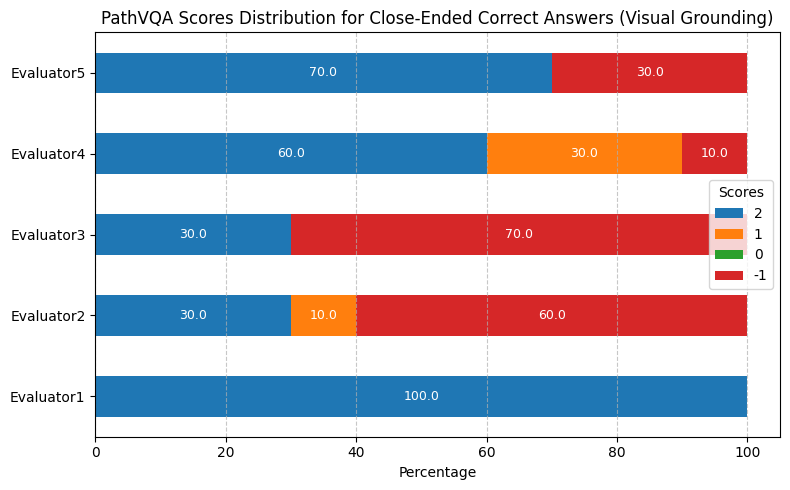

In [20]:
ax = correct_answers_close_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('PathVQA Scores Distribution for Close-Ended Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathvqa_close_ended_correct_answers_vis_grounding.png')
plt.show()